In [1]:
import cv2
import numpy as np
import os

input_dir = "white_patch"
output_dir = "white_patch_res"

os.makedirs(output_dir, exist_ok=True)

def white_patch(img):
    img = img.astype(np.float32)

    # máximo por canal
    max_vals = img.reshape(-1, 3).max(axis=0)

    # evitar división por cero
    max_vals[max_vals == 0] = 1

    # escalar
    img_wp = img / max_vals * 255.0

    return np.clip(img_wp, 0, 255).astype(np.uint8)

# recorrer imágenes
for filename in os.listdir(input_dir):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(input_dir, filename)

        img = cv2.imread(path)
        if img is None:
            continue

        result = white_patch(img)

        # guardar en la salida las imagenes
        out_path = os.path.join(output_dir, filename)
        cv2.imwrite(out_path, result)

print("Procesamiento terminado")



Procesamiento terminado


#
PARTE 2 -VISUALIZAR LAS IMAGENES EN ESCALA DE GRISES

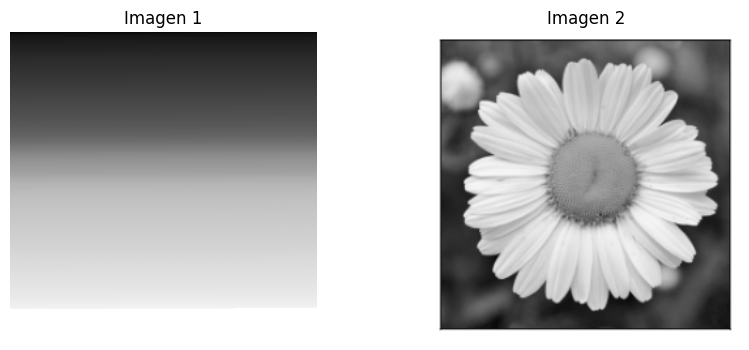

In [2]:
import matplotlib.pyplot as plt
img1 = cv2.imread("img1_tp.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("img2_tp.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Imagen 1")
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Imagen 2")
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.show()

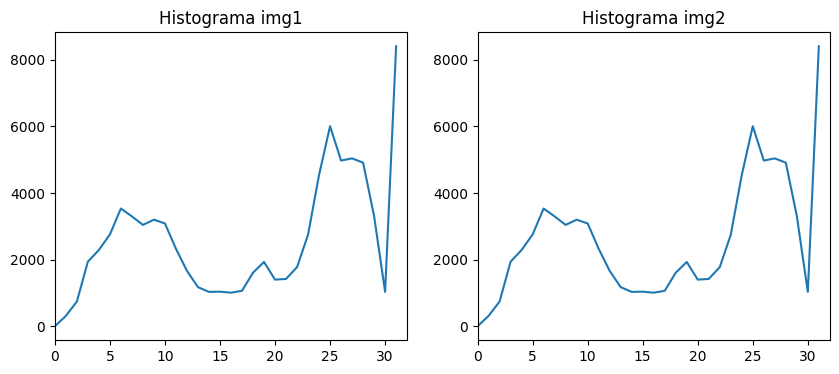

In [9]:
# Elegimos número de bins probamos con potencias de dos
bins = 32 #[32, 64, 128, 256]

# Comparamos Histogramas
hist1 = cv2.calcHist([img1], [0], None, [bins], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [bins], [0, 256])

# Graficar
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Histograma img1")
plt.plot(hist1)
plt.xlim([0, bins])

plt.subplot(1,2,2)
plt.title("Histograma img2")
plt.plot(hist2)
plt.xlim([0, bins])

plt.show()

#Análisis y Conclusiones

**Elección de bins**





Si bien los histogramas capturan la distribución global de intensidades, en este caso no parecen ser suficientemente discriminativos, ya que ambas imágenes presentan distribuciones muy similares. Por lo tanto, su uso como única característica en un modelo de clasificación podría no sumar beneficio.